In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.interpolate import CubicSpline as cs
plt.style.use(['science', 'notebook', 'grid'])

In [54]:
HD = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_0_results.txt', delim_whitespace=True)
HEL = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_7_results.txt', delim_whitespace=True)
CMB = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_8_results.txt', delim_whitespace=True)
LG = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_9_results.txt', delim_whitespace=True)




/tmp/ipykernel_24046/3115096394.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  HD = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_0_results.txt', delim_whitespace=True)
/tmp/ipykernel_24046/3115096394.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  HEL = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_7_results.txt', delim_whitespace=True)
/tmp/ipykernel_24046/3115096394.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  CMB = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_8_results.txt', delim_whitespace=True)
/tmp/ipykernel_24046/3115096394.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated 

In [55]:
dfcmb = pd.read_csv('CMB_C1.csv', sep=',')
dfhel = pd.read_csv('HEL_C1.csv', sep=',')
dfhd = pd.read_csv('HD_C1.csv', sep=',')
dflg = pd.read_csv('LG_C1.csv', sep=',')

In [56]:
ZINDEX_MAPPING={0:'HD',7:'HEL',8:'CMB',9:'LG'}
ZINDEX = 9 
true_vals = pd.read_csv(f'{ZINDEX_MAPPING[ZINDEX]}_C1.csv')
profile=[]
for zlim in true_vals['zlim']:
    print("Working on zlim: ",zlim)
    qm_best= true_vals['qm'][true_vals['zlim']==zlim].values[0]
    qm_vary = np.linspace(qm_best - 0.3, qm_best + 0.3, 30)
    print('Range of qm: ', qm_vary[0], qm_vary[-1])

Working on zlim:  0.00587
Range of qm:  -0.3159093979 0.2840906021
Working on zlim:  0.00907
Range of qm:  -0.357047364 0.242952636
Working on zlim:  0.01351
Range of qm:  -0.34117540949999997 0.2588245905
Working on zlim:  0.01613
Range of qm:  -0.3260213313 0.2739786687
Working on zlim:  0.01826
Range of qm:  -0.32272326079999997 0.2772767392
Working on zlim:  0.02121
Range of qm:  -0.3426261432 0.25737385679999997
Working on zlim:  0.02324
Range of qm:  -0.3289599533 0.2710400467
Working on zlim:  0.02531
Range of qm:  -0.34932363029999997 0.2506763697
Working on zlim:  0.02873
Range of qm:  -0.34520160499999997 0.254798395
Working on zlim:  0.03139
Range of qm:  -0.35644564019999997 0.24355435979999998
Working on zlim:  0.03486
Range of qm:  -0.35522115 0.24477885
Working on zlim:  0.04146
Range of qm:  -0.431874422 0.168125578
Working on zlim:  0.05057
Range of qm:  -0.442086382 0.15791361799999998
Working on zlim:  0.06976
Range of qm:  -0.458060853 0.141939147
Working on zlim:  

In [57]:
def analyze_profiles(df_profile, df_bestfit,plot=False):
    final_vals = {}
    qm= []
    mle = []
    roots = []
    for zlim in df_profile['zlim'].unique():
        df_subset = df_profile[df_profile['zlim'] == zlim] .sort_values('qm_vary')
        df_min = df_bestfit[df_bestfit['zlim'] == zlim]   
        x = df_subset['qm_vary']
        y = df_subset['res'] - np.min(df_subset['res'])

        root = cs(x,y - 1, bc_type='natural').roots()

        #plt.plot(x,y,'.')


        #plt.plot(df_min['p8'], 0, '*', markersize=10, label=f'Best fit: {np.array(df_min["p8"])[0]:.3f}')
        np.isclose(df_min['qm'],root)
        q_best = np.array(df_min['qm'])[0]
        if len(root) >= 2:
            left_roots  = root[root < q_best]
            right_roots = root[root > q_best]
            roots_phys = []
            if len(left_roots) > 0:
                roots_phys.append(left_roots.max())   # closest from left
            if len(right_roots) > 0:
                roots_phys.append(right_roots.min())  # closest from right
            if plot:
                plt.plot(roots_phys, np.ones_like(roots_phys), 'o', label=f'Roots (±1σ)')
        if plot:
            plt.plot(x, y, label='Likelihood profile')
            plt.axhline(y=1, color='k', linestyle='--', alpha=0.3)
            plt.xlabel('$q_m$')
            plt.ylabel('$\Delta(-2\log L)$')
            plt.title(f'zLIM = {zlim:.5f}')
            plt.legend()
            plt.grid(True, alpha=0.3)
        qm.append(np.array(df_min['qm'])[0])
        roots.append(roots_phys)
        plt.show()
    final_vals['zlim'] = df_profile['zlim'].unique()
    final_vals['QM'] = qm
    final_vals['root'] = roots

    df_return = pd.DataFrame(final_vals)
    return df_return

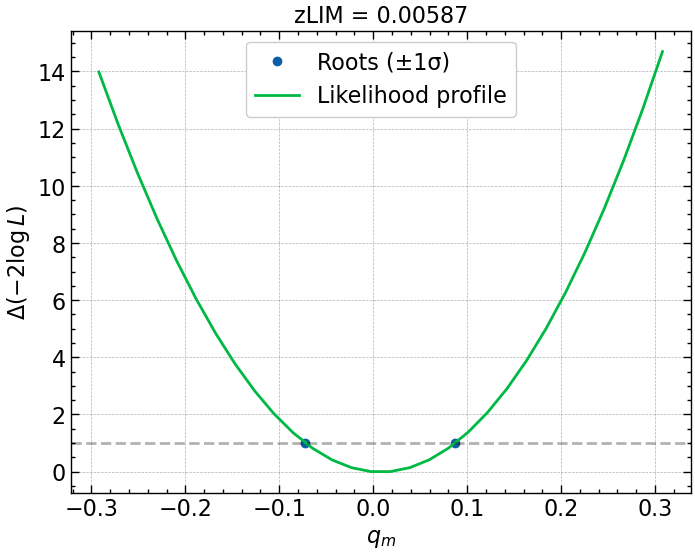

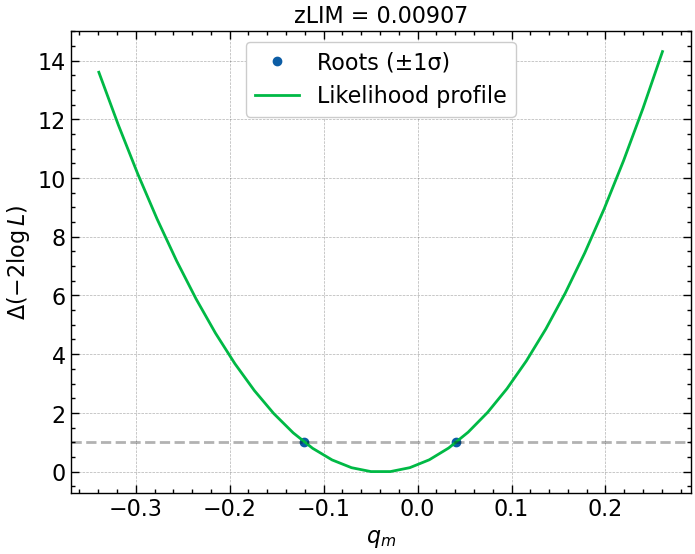

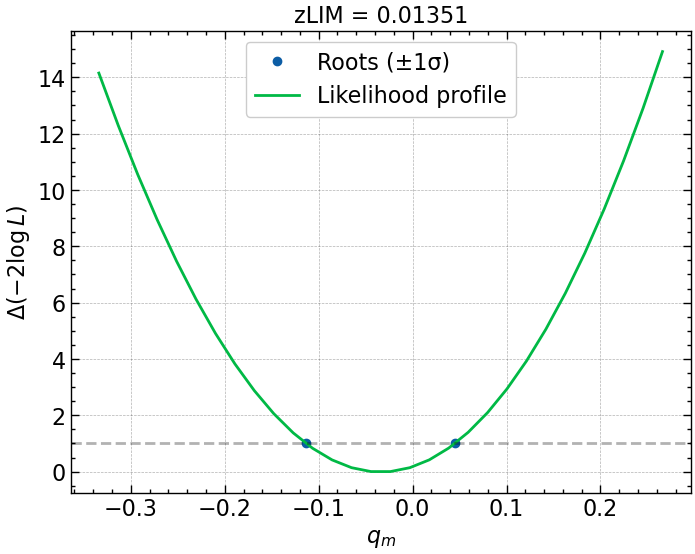

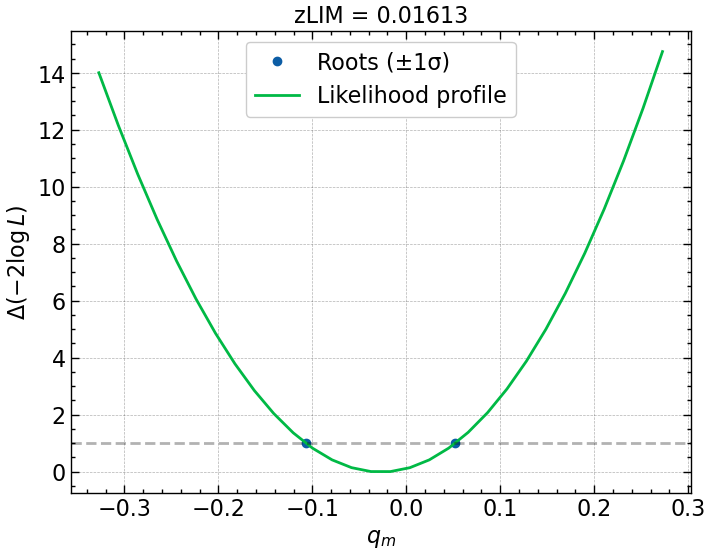

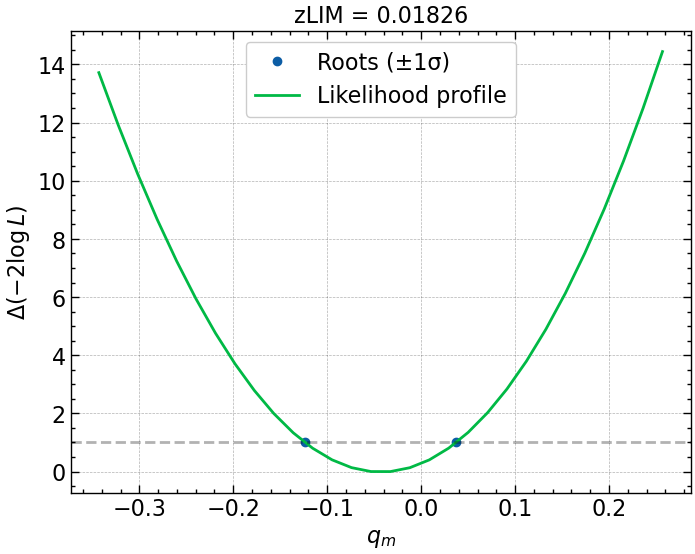

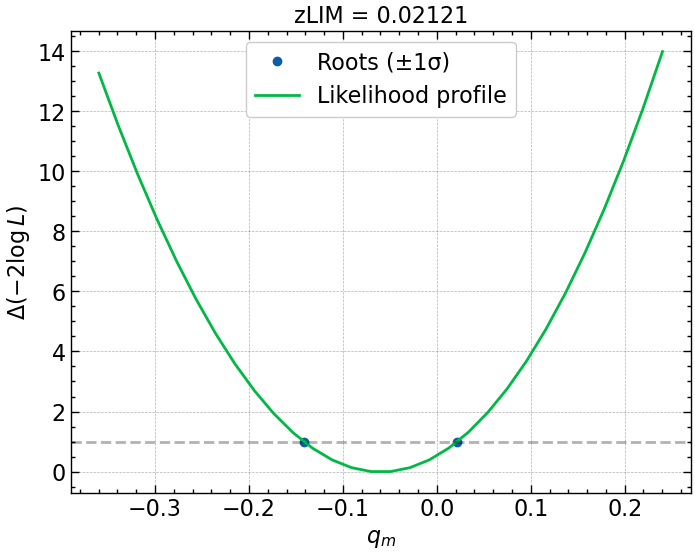

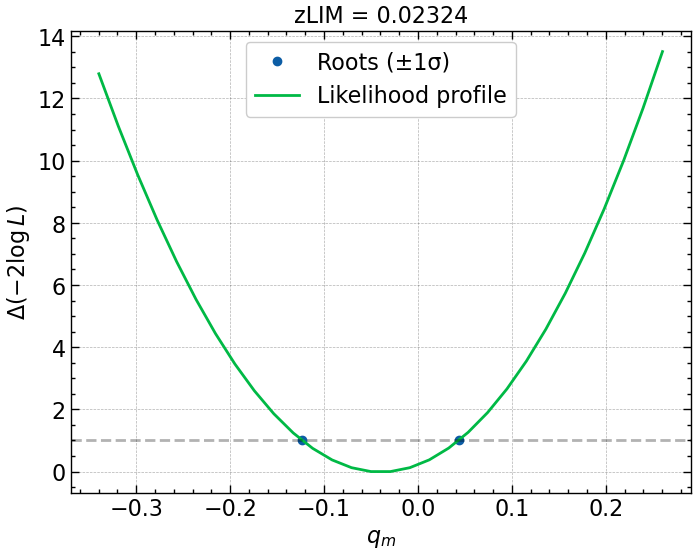

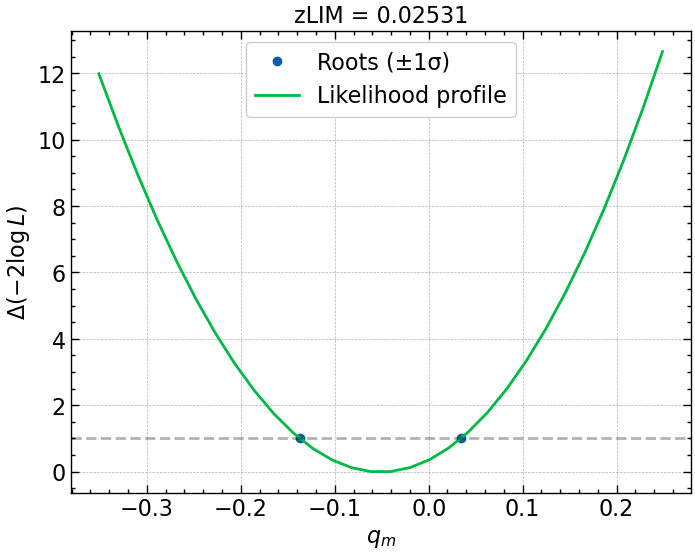

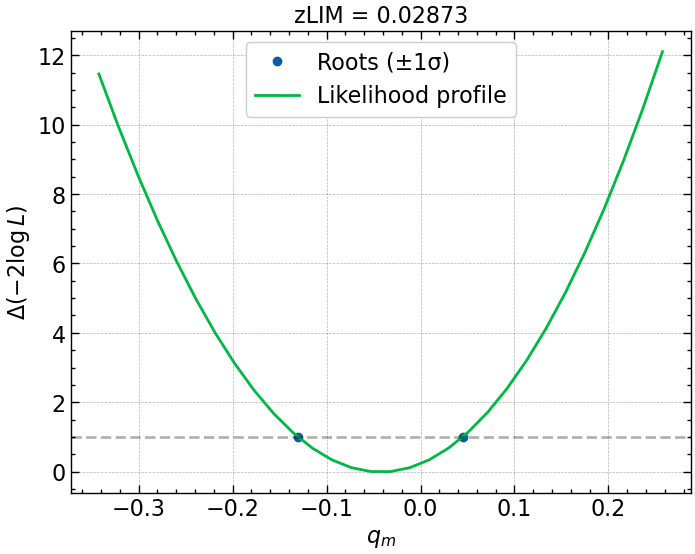

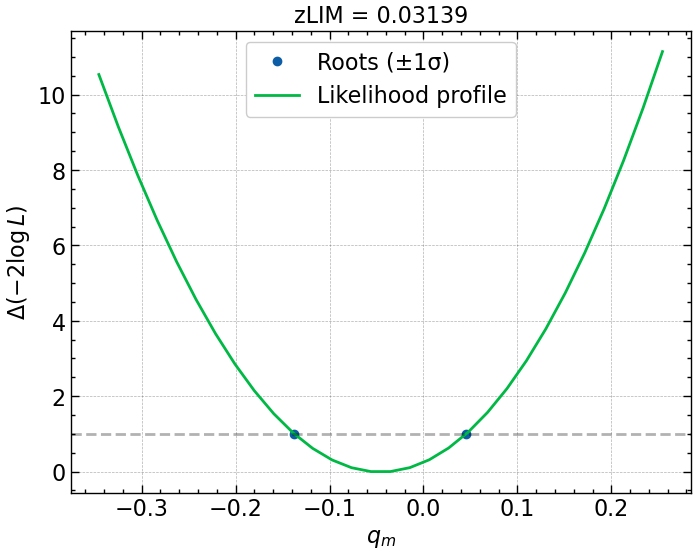

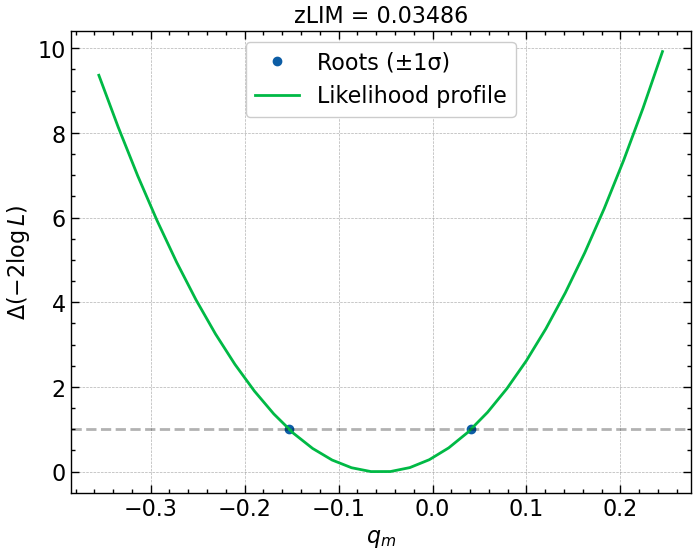

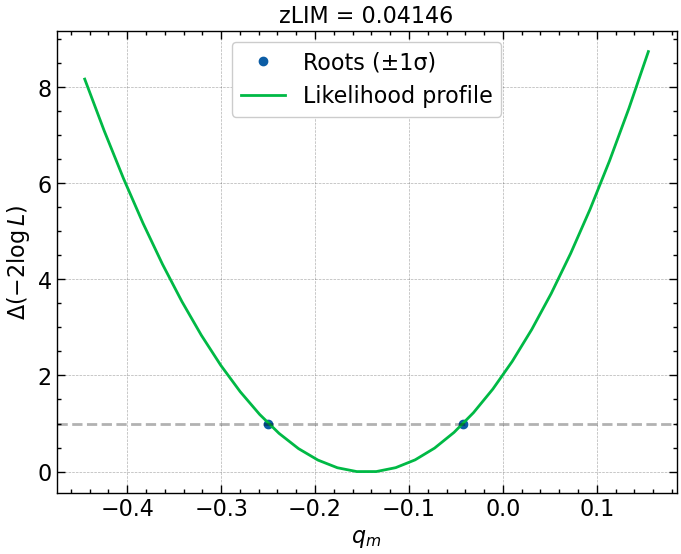

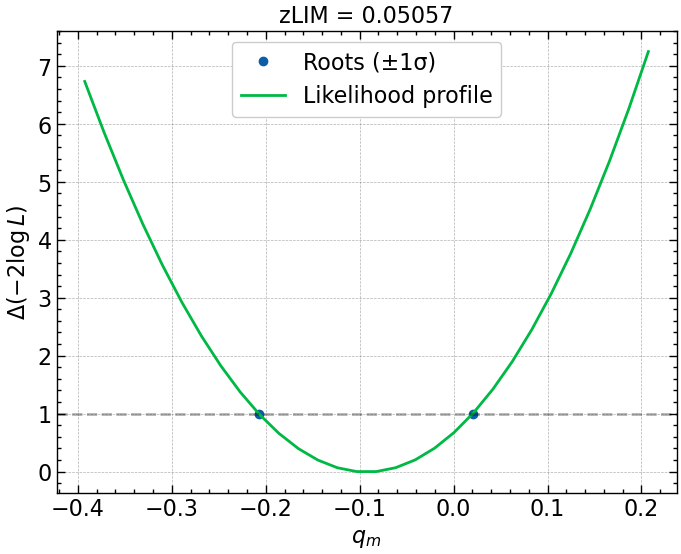

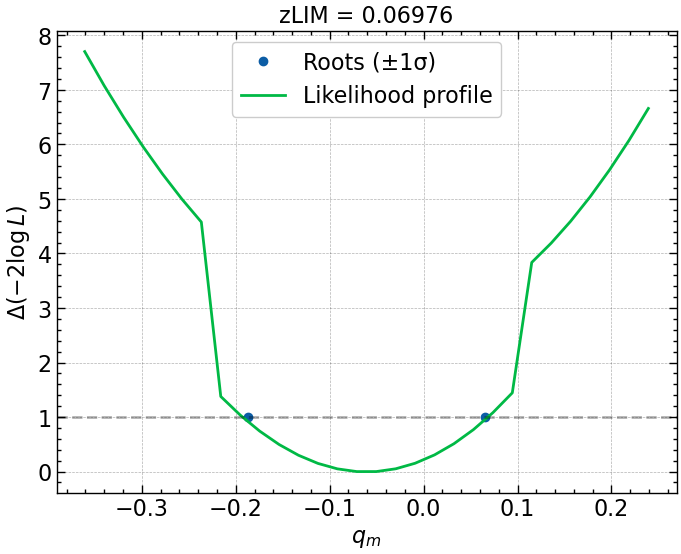

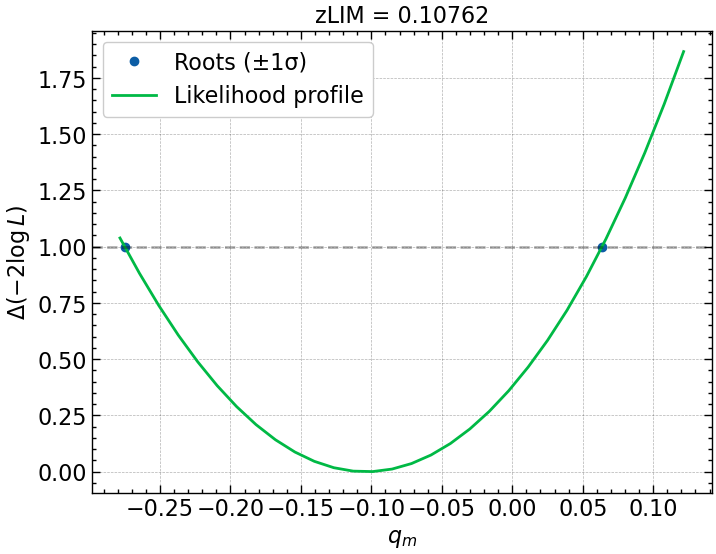

In [62]:
df_errors_hd = analyze_profiles(HD, dfhd, plot=False)
df_errors_hel = analyze_profiles(HEL, dfhel, plot=False)
df_errors_cmb = analyze_profiles(CMB, dfcmb, plot=True)
df_errors_lg = analyze_profiles(LG, dflg, plot=False)





In [65]:
df_errors_hd.to_csv('HD_QM_errors_C1_age_bias.csv', index=False)
df_errors_hel.to_csv('HEL_QM_errors_C1_age_bias.csv', index=False)
df_errors_cmb.to_csv('CMB_QM_errors_C1_age_bias.csv', index=False)
df_errors_lg.to_csv('LG_QM_errors_C1_age_bias.csv', index=False)

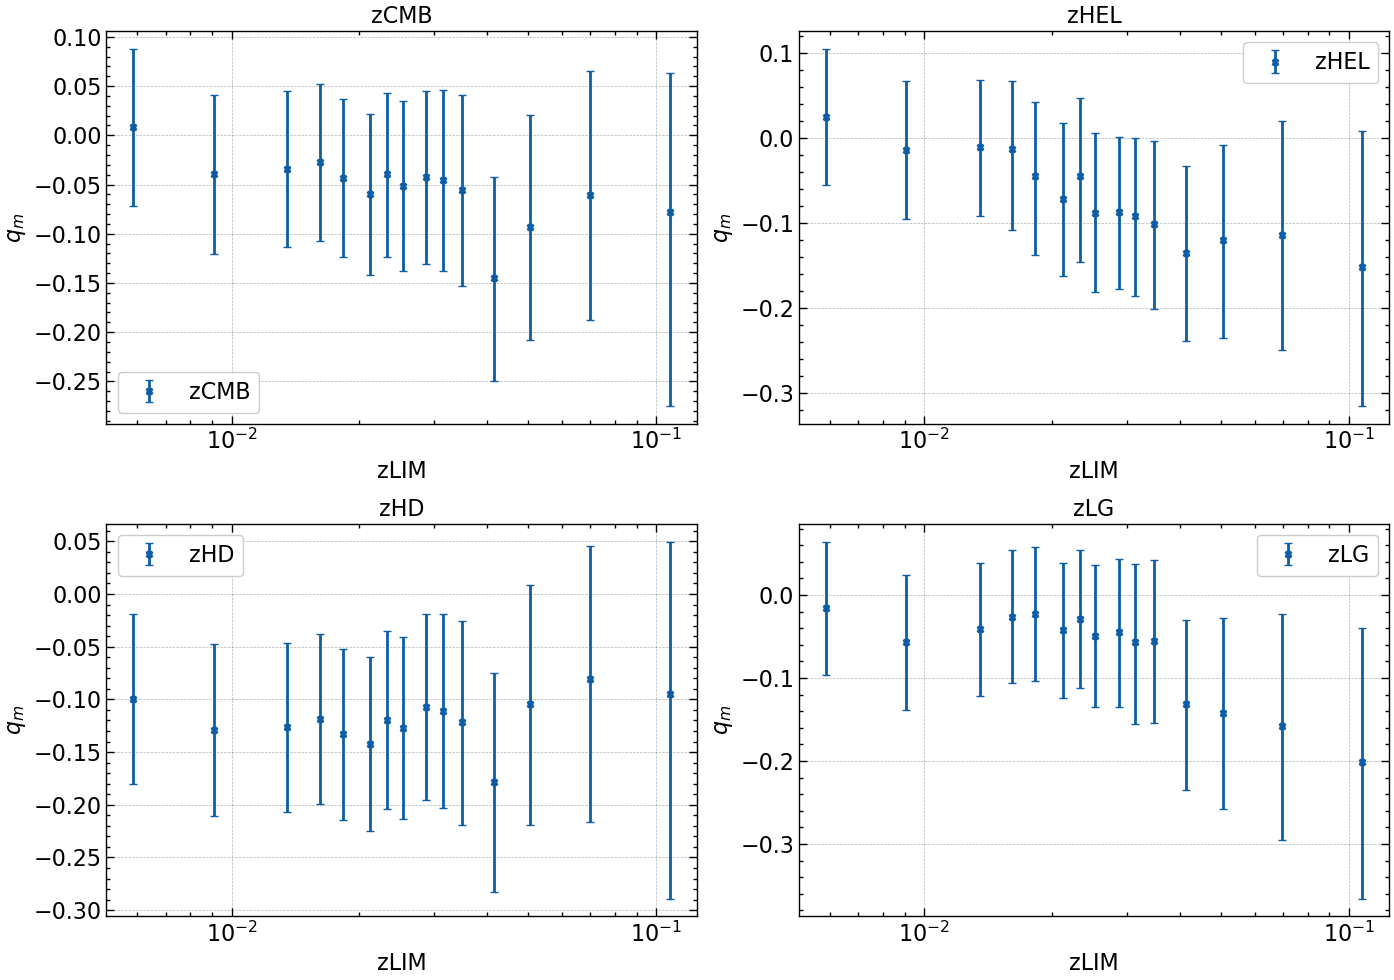

In [60]:
ar = ['CMB', 'HEL', 'HD', 'LG']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, a in enumerate(ar):
    ax = axes[idx]
    df_min = globals()[f"df_errors_{a.lower()}"]
    
    zlims = df_min['zlim'].values
    qm_best = df_min['QM'].values
    
    yerr_low = []
    yerr_high = []
    
    for i, roots_str in enumerate(df_min['root']):
        roots = roots_str
        roots = np.array(roots)
        q_best = qm_best[i]
        
        left_roots = roots[roots < q_best]
        right_roots = roots[roots > q_best]
        

        err_low = q_best - left_roots


        err_high = right_roots - q_best

            
        yerr_low.append(err_low[0])
        yerr_high.append(err_high[0])
    
    ax.errorbar(zlims, qm_best, yerr=[yerr_low, yerr_high], 
                fmt='X', label=f'z{a}', capsize=3, markersize=5)
    
    ax.set_xlabel("zLIM")
    ax.set_ylabel("$q_m$")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_title(f'z{a}')

plt.tight_layout()
plt.show()

In [ ]:
yerr_low

[np.float64(0.12034377680405507),
 np.float64(0.07922968133163581),
 np.float64(0.09476152824134718),
 np.float64(0.1098810791093558),
 np.float64(0.11315375747078446),
 np.float64(0.09326484722896244),
 np.float64(0.10707904177749342),
 np.float64(0.0866949156296338),
 np.float64(0.09067235434629495),
 np.float64(0.07989407349336422),
 np.float64(0.08125962969942044),
 np.float64(0.004131794259401272),
 np.float64(0.5613715997200261),
 np.float64(0.5682117974718284),
 np.float64(0.5862800065395041)]